## 5.4 Exercise 4

The power radiation pattern for a horn antenna extended in the E-plane has to be calculated in the E-plane
( $\theta$ = 0) for angles from  $\theta$ = 0° to  $\theta$ = 180° and plotted in polar cooradinates.
- State the formulas to calculate the amplitudes in the far field and plot them in 1°-steps in a Matlab plot
(in dB).
- State the needed formulas and calculate the following values. Also, draw them by hand in your Matlab
plot.
– The first 4 nulls
– The half power beam width (approximative formula)
Dimensions of the antenna aperture: a = 2:3 cm, b = 12 cm, frequency f = 11.85 GHz.

### E-plane Radiation Pattern with Nulls and HPBW

This nex plot shows the normalized far-field radiation pattern of a horn antenna extended in the E-plane.  
The **red circles** mark the first four nulls w.r.t. the main lobe at 90°.  
The **green dots** indicate the **Half Power Beam Width (HPBW)** — the angular region where the radiated power is within 3 dB of the maximum (half power).
This region represents the main lobe of the antenna's radiation pattern.

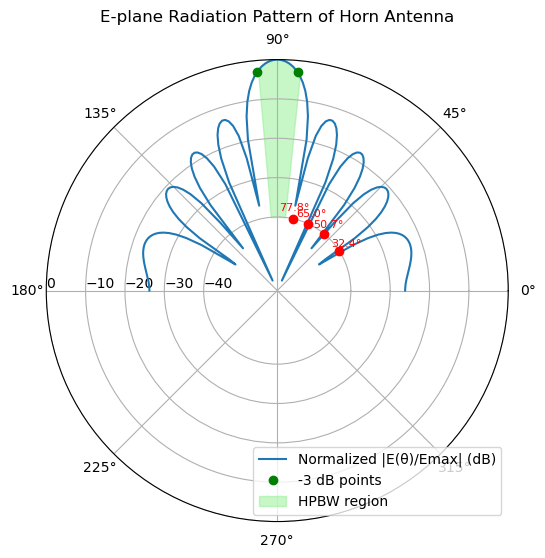

Wavelength λ = 2.532 cm
Approximate Half Power Beam Width (HPBW) ≈ 10.76°
First 4 nulls at angles (deg): ['77.82', '65.04', '50.73', '32.45']


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
c = 3e8  # speed of light in m/s
f = 11.85e9  # frequency in Hz
λ = c / f  # wavelength in meters
b_prime = 0.12  # aperture size in the E-plane (in meters)
beta = 2 * np.pi / λ  # wave number

# --- Angular range (0° to 180°) ---
theta_deg = np.arange(0, 181, 1)
theta_rad = np.radians(theta_deg)

# --- Compute B = (b' * beta * cos(theta)) / 2 ---
B = (b_prime * beta * np.cos(theta_rad)) / 2
B[B == 0] = 1e-12  # Avoid division by zero

# --- Compute normalized far-field amplitude |U(theta)/Umax| = |sin(B)/B| ---
U_norm = np.abs(np.sin(B) / B)
U_dB = 20 * np.log10(U_norm / np.max(U_norm))  # normalized in dB

# --- Compute approximate HPBW ---
HPBW = 51 * λ / b_prime  # in degrees

# --- Find first 4 nulls: B = nπ --> cos(θ_null) ---
null_angles = []
for n in range(1, 5):
    B_null = n * np.pi
    cos_theta_null = 2 * B_null / (b_prime * beta)
    if np.abs(cos_theta_null) <= 1:
        theta_null = np.degrees(np.arccos(cos_theta_null))
        null_angles.append(theta_null)

# --- Plot in polar coordinates ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, polar=True)

# Plot radiation pattern
ax.plot(np.radians(theta_deg), U_dB, label="Normalized |E(θ)/Emax| (dB)")

# Mark nulls
for angle in null_angles:
    ax.plot(np.radians(angle), [-40], 'ro')
    ax.text(np.radians(angle), -38, f'{angle:.1f}°', color='red', ha='center', fontsize=8)

# Mark -3 dB points (HPBW limits)
half_beam = HPBW / 2
left_bound = 90 - half_beam
right_bound = 90 + half_beam
ax.plot(np.radians(left_bound), [-3], 'go', label='-3 dB points')
ax.plot(np.radians(right_bound), [-3], 'go')

# Shade HPBW region in light green
theta_fill = np.radians(np.arange(int(left_bound), int(right_bound) + 1))
radius_fill = np.interp(theta_fill, np.radians(theta_deg), U_dB)
ax.fill_between(theta_fill, radius_fill, -40, color='lightgreen', alpha=0.5, label='HPBW region')

# Final plot settings
ax.set_title("E-plane Radiation Pattern of Horn Antenna", va='bottom')
ax.set_rticks([-40, -30, -20, -10, 0])
ax.set_rlabel_position(180)
ax.grid(True)
ax.legend(loc='lower right')
plt.show()

# --- Print Results ---
print("Wavelength λ = {:.3f} cm".format(λ * 100))
print("Approximate Half Power Beam Width (HPBW) ≈ {:.2f}°".format(HPBW))
print("First 4 nulls at angles (deg):", [f"{a:.2f}" for a in null_angles])

## 5.5 Exercise 5

You are building a 13 GHz communication link between two office buildings with two identical antennas.
The main beams of both antennas are oriented against each other. Both antennas have a gain of 9 dBi. The
transmit power $PT_{x}$ is 6dBm. The length of the communication link is 100m. Calculate the receive power
$PR_{x}$.
You observe that the system is not working. You hear from the manufacturer of the receiver that the receive
power must be at least $PR_{x}$ = -60dBm for the communication link to work. To reach this receive power,
only one antenna shall be exchanged. Calculate the gain of the new antenna (in dBi).

### Part 1: Calculate Received Power

This section uses the Friis transmission equation to calculate the received power at 13 GHz over a 100 m link using two antennas with 9 dBi gain. From the result, the minimum receive power is not achieved:

In [2]:
# --- Part 1: Compute received power with both antennas having 9 dBi gain ---

# Given values
c = 3e8  # speed of light [m/s]
f = 13e9  # frequency [Hz]
λ = c / f  # wavelength [m]
r = 100  # distance [m]
Pt_dBm = 6  # transmit power [dBm]
G1_dBi = 9  # gain of antenna 1 [dBi]
G2_dBi = 9  # gain of antenna 2 [dBi]

# Friis transmission formula in dB
path_loss_dB = 20 * np.log10(λ / (4 * np.pi * r))
Pr_dBm = Pt_dBm + G1_dBi + G2_dBi + path_loss_dB

# Output
print("=== PART 1 ===")
print(f"Wavelength λ = {λ*100:.2f} cm")
print(f"Path Loss = {path_loss_dB:.2f} dB")
print(f"Received Power = {Pr_dBm:.2f} dBm")

=== PART 1 ===
Wavelength λ = 2.31 cm
Path Loss = -94.72 dB
Received Power = -70.72 dBm


### Part 2: Determine Required Gain

This next section calculates the minimum gain needed for a replacement antenna to meet the link budget.

In [3]:
# --- Part 2: Compute required gain of new antenna if system doesn't meet threshold ---

Rx_min_dBm = -60  # minimum receive power for link to work

# Compute required gain of one antenna if only one is replaced
G_new_dBi = Rx_min_dBm - Pr_dBm + G1_dBi
print("\n=== PART 2 ===")
print(f"Minimum required gain of replacement antenna: {G_new_dBi:.2f} dBi")

# Optional: verify by recalculating received power
Pr_dBm_check = Pt_dBm + G1_dBi + G_new_dBi + path_loss_dB
print(f"Recomputed received power with new antenna: {Pr_dBm_check:.2f} dBm")



=== PART 2 ===
Minimum required gain of replacement antenna: 19.72 dBi
Recomputed received power with new antenna: -60.00 dBm
